# Problem set 4: Descriptive economics I - comments/solutions

# Programming for Economists Summer 2026: Class 9
**Matias BF Hall**

**Table of contents**<a id='toc0_'></a>    
- 1. [Basic pandas](#toc1_)    
  - 1.1. [Dataframe](#toc1_1_)    
  - 1.2. [New variable](#toc1_2_)    
  - 1.3. [Indexing](#toc1_3_)    
    - 1.3.1. [**Note that the exact same operation in terms of indexing in Pandas can be done in many ways**](#toc1_3_1_)    
  - 1.4. [Changing variables](#toc1_4_)    
  - 1.5. [Dropping observations and columns](#toc1_5_)    
  - 1.6. [Renaming](#toc1_6_)    
  - 1.7. [Income distribution](#toc1_7_)    
    - 1.7.1. [Bonus](#toc1_7_1_)    
- 2. [Inflation](#toc2_)    
  - 2.1. [Basics](#toc2_1_)    
  - 2.2. [Instantaneous inflation](#toc2_2_)    
  - 2.3. [Core inflation](#toc2_3_)    
  - 2.4. [CPI vs HICP](#toc2_4_)    
  - 2.5. [International comparison](#toc2_5_)    

<!-- vscode-jupyter-toc-config
	numbering=true
	anchor=true
	flat=false
	minLevel=2
	maxLevel=6
	/vscode-jupyter-toc-config -->
<!-- THIS CELL WILL BE REPLACED ON TOC UPDATE. DO NOT WRITE YOUR TEXT IN THIS CELL -->

In [2]:
# Uncomment below to install the required package

# %pip install git+https://github.com/alemartinello/dstapi
# %pip install fredapi

In [3]:
import numpy as np

import pandas as pd
from IPython.display import display

import matplotlib.pyplot as plt
plt.rcParams.update({'axes.grid':True,'grid.color':'black','grid.alpha':'0.25','grid.linestyle':'--'})
plt.rcParams.update({'font.size': 14})

from dstapi import DstApi
from fredapi import Fred

## 1. <a id='toc1_'></a>[Basic pandas](#toc0_)

### 1.1. <a id='toc1_1_'></a>[Dataframe](#toc0_)

Modify the code below such that *income* and *consumption* are variables in the *df* DataFrame.

In [4]:
# Set random seed for replicability
np.random.seed(1999)

# Set number of observations, N
N = 100

# Create data, first an empty dictionary
mydata = {}
# Fill the dictionary with an id from 0 to N-1(0-99)
mydata['id'] = range(N)

# Define income as a log-normally distributed variable with N observations
# and consumption as a concave function of income
income = np.exp(np.random.normal(size=N))
consumption = np.sqrt(income)

# Add income and consumption to the dictionary
mydata['income'] = income
mydata['consumption'] = consumption

# Create a dataframe from the dictionary - we name it df
df = pd.DataFrame(mydata)

# Alternatively, create the dataframe first and then add income and consumption
#df['income'] = income
#df['consumption'] = consumption

# Print the first five rows of the dataframe
df.head()

,id,income,consumption
0,0,0.727981,0.853218
1,1,1.997831,1.413447
2,2,0.276823,0.526140
3,3,1.481931,1.217346
4,4,1.235904,1.111712


In [5]:
# Display the whole(truncated) dataframe
display(df)

,id,income,consumption
0,0,0.727981,0.853218
1,1,1.997831,1.413447
2,2,0.276823,0.526140
3,3,1.481931,1.217346
4,4,1.235904,1.111712
...,...,...,...
95,95,0.201856,0.449284
96,96,2.368034,1.538842
97,97,2.389874,1.545922
98,98,1.488635,1.220096


### 1.2. <a id='toc1_2_'></a>[New variable](#toc0_)

Create a new variable *ratio* which is the ratio of consumption to income.

In [6]:
# we can add it directly to the dataframe, using the dataframe columns
df['ratio'] = df['consumption']/df['income']
# or define ratio first and then add it to the dataframe
# ratio = consumption/income
# df['ratio'] = ratio
df.head()

,id,income,consumption,ratio
0,0,0.727981,0.853218,1.172033
1,1,1.997831,1.413447,0.707490
2,2,0.276823,0.526140,1.900636
3,3,1.481931,1.217346,0.821459
4,4,1.235904,1.111712,0.899513


### 1.3. <a id='toc1_3_'></a>[Indexing](#toc0_)

#### 1.3.1. <a id='toc1_3_1_'></a>[**Note that the exact same operation in terms of indexing in Pandas can be done in many ways**](#toc0_)
See the examples below here. To my knowledge direct access can not be used for everything, especially not when the selction of the data source becomes more complicated. So I suppose it would be a good habit to use loc from the getgo, even though it might seem redundant, for the current level of complexity.

**Question a:** Select everybody: with an income above 1.

In [7]:
# we can filter the dataframe directly using boolean indexing
df[df['income'] > 1].head()

# we can do the same using the loc method
# df.loc[df['income'] > 1].head()

# we can even access the columns through the dataframe attribute
# df[df.income > 1].head()

# As stated above, loc is the most "right" way to do it, but I think for this course 
# it is ok to use the one you find the most intuitive

,id,income,consumption,ratio
1,1,1.997831,1.413447,0.707490
3,3,1.481931,1.217346,0.821459
4,4,1.235904,1.111712,0.899513
6,6,2.574032,1.604379,0.623294
7,7,2.475478,1.573365,0.635580


**Question b:** Select everybody with an income *above* 1 and a ratio *above* 0.7.

In [8]:
# We can also combine several conditions using & (and) and | (or)
# Remember to put each condition in parentheses
I = (df['income'] > 1) & (df['ratio'] > 0.7)
df.loc[I].head()

,id,income,consumption,ratio
1,1,1.997831,1.413447,0.707490
3,3,1.481931,1.217346,0.821459
4,4,1.235904,1.111712,0.899513
11,11,2.031708,1.425380,0.701567
18,18,1.280235,1.131475,0.883802


### 1.4. <a id='toc1_4_'></a>[Changing variables](#toc0_)

**Question a:** Set consumption equal to 0.5 if income is less than 0.5.

In [9]:
# Index for those with income below 0.5
I = df['income'] < 0.5

# Create a new dataframe where those with income below 0.5 have consumption set to 0.5
df_forced = df.copy()
df_forced.loc[I, 'consumption'] = 0.5
# You can read the indexing as: for those rows where I is true, set the consumption column to 0.5

# Compare
print(f'Original consumption mean: {df['consumption'].mean()}') # <- compare with answer
print(f'Consumption mean with forced consumption: {df_forced['consumption'].mean()}')

# Overall forcing poor consumers to consume less than they would want(sqrt of income), decreases average consumption
# Even though we force some consumers to consume more than they would want, the net effect is a decrease in average consumption

Original consumption mean: 1.0878444061731818
Consumption mean with forced consumption: 1.075479712048503


**Question b:** Set consumption equal to income if income is less than 0.5.

In [10]:
# Index for those with income below 0.5
I = df['income'] < 0.5

# Create a new dataframe where those with income below 0.5 have consumption set to income(hand to mouth consumers)
df_htm = df.copy()
df_htm.loc[I, 'consumption'] = df_htm.loc[I, 'income']

# Compare
print(f'Original consumption mean: {df['consumption'].mean()}') # <- compare with answer
print(f'Consumption mean with hand to mouth: {df_htm['consumption'].mean()}')
# Overall making poor consumers hand to mouth, decreases average consumption as they were all borrowers before

Original consumption mean: 1.0878444061731818
Consumption mean with hand to mouth: 1.0337728690050054


### 1.5. <a id='toc1_5_'></a>[Dropping observations and columns](#toc0_)

Drop the *ratio* variable and all rows with an income above 1.5. After this, also drop the first 5 rows.

In [11]:
# Keep in mind we cannot drop e.g. the coloumn 'ratio' more than once, so make sure to run from the start if you want to try again
# You can also make a copy of the dataframe first and then drop in the copy so the codeblock below can be run multiple times
# df2 = df.copy() # change df to df2 below if you do this

print(f'before: {df.shape[0]} observations, {df.shape[1]} variables')
# Since we cannot drop rows directly, we need to reassign the dataframe to itself after dropping rows/columns
df = df.drop('ratio', axis=1) # axis=1 means we drop a column, axis=0 would mean we drop a row
df = df.drop(df[df['income'] > 1.5].index) # drop all rows where income is above 1.5, using the index attribute that gives the row indices
df = df.drop(df[:5].index) # drop the first five rows, again using the index attribute
# alternatively we can index directly using iloc
#df = df.iloc[5:] # drop the first five rows using iloc where we can index directly by position
print(f'after: {df.shape[0]} observations, {df.shape[1]} variables')

before: 100 observations, 4 variables
after: 65 observations, 3 variables


In [12]:
df.head()

,id,income,consumption
8,8,0.582074,0.762938
10,10,0.932044,0.965424
12,12,0.356952,0.597454
13,13,0.379825,0.616299
16,16,0.700896,0.837195


In [13]:
# We can reset the index after dropping rows, so that the index runs from 0 to n-1 again
# This is not strictly necessary, but can be useful
df = df.reset_index(drop=True) # reset the index, drop=True means we do not keep the old index as a column
df.head() #check before and after by running df.head() before and after the reset

,id,income,consumption
0,8,0.582074,0.762938
1,10,0.932044,0.965424
2,12,0.356952,0.597454
3,13,0.379825,0.616299
4,16,0.700896,0.837195


### 1.6. <a id='toc1_6_'></a>[Renaming](#toc0_)

Rename *consumption* to *cons* and *income* to *inc*.

In [14]:
# Run the code from the start to get the right results below, and uncomment your 
# preferred renaming method or to check that they all give the same result

# We can rename columns in several ways

# We can rename all columns at once
print(df.columns) # print current column names to make sure we change the right ones
df.columns = ['id', 'inc', 'cons']  # Rename all columns at once

# We can rename a single column using a list comprehension
# df.columns = [col if col != 'income' else 'inc' for col in df.columns]
# The above reads: for each column in the current columns, if the column is not 'income', keep it the same, otherwise change it to 'inc'

# Alternatively, we can use the rename method
# df = df.rename(columns={'income': 'inc', 'consumption': 'cons'})
# The above reads: rename the column 'income' to 'inc' and 'consumption' to 'cons'

# The most simple way to rename a single column is to just assign to it directly and then drop the old column
#df['inc'] = df['income']
#df = df.drop('income', axis=1)
#df['cons'] = df['consumption']
#df = df.drop('consumption', axis=1)
# This is not very efficient if you have many columns to rename, but it works

df.head()

Index(['id', 'income', 'consumption'], dtype='object')


,id,inc,cons
0,8,0.582074,0.762938
1,10,0.932044,0.965424
2,12,0.356952,0.597454
3,13,0.379825,0.616299
4,16,0.700896,0.837195


In [15]:
# Create the true dataframe again to have the original data for the next exercises
# Set seed again to get the same data
np.random.seed(1999)
N = 100
mydata = {}
mydata['id'] = range(N)
mydata['income'] = np.exp(np.random.normal(size=N))
mydata['consumption'] = np.sqrt(mydata['income'])

df_true = pd.DataFrame(mydata)

df_true = df_true.rename(columns={'income':'inc','consumption':'con'})
df_true.head()

,id,inc,con
0,0,0.727981,0.853218
1,1,1.997831,1.413447
2,2,0.276823,0.526140
3,3,1.481931,1.217346
4,4,1.235904,1.111712


### 1.7. <a id='toc1_7_'></a>[Income distribution](#toc0_)

Compute the share of income for each decile of the income distribution using the code below as a starting point.

In [16]:
# Create the deciles - Jeppe does this using list comprehension but I just do it manually
deciles = df_true.quantile([.1, .2, .3, .4, .5, .6, .7, .8, .9])
#deciles = df_true.quantile([d/10 for d in np.arange(1,10)) # alternative way to create the deciles using list comprehension
# the quantile method returns the value at each requested quantile for each column(unless another axis is specified)

# We can use the above computed deciles as bins in the cut function. We add -inf and inf to make sure all values are included
df_true['deciles'] = pd.cut(df_true['inc'], bins=[-np.inf] + list(deciles['inc']) + [np.inf], labels=range(1,11))

# Alternatively we can use the qcut function that does the same in one step
# This seperates into quantiles directly, 10 is for deciles
df_true['decile'] = pd.qcut(df_true['inc'], 10, labels=range(1,11))

# Using the group by method we can now compute the income shares by decile
# You can read it as: take the sum of income for each decile, then divide by the total income
income_shares = df_true.groupby('deciles', observed=True)['inc'].sum() / df_true['inc'].sum()

# Check that the cut and qcut solutions are the same
income_shares_extra = df_true.groupby('decile', observed=True)['inc'].sum() / df_true['inc'].sum()
assert np.allclose(income_shares, income_shares_extra)

display(income_shares)
# display is a bit better than print for dataframes and series

deciles
1     0.014112
2     0.027632
3     0.037195
4     0.049923
5     0.064946
6     0.079174
7     0.099996
8     0.126800
9     0.178850
10    0.321371
Name: inc, dtype: float64

#### 1.7.1. <a id='toc1_7_1_'></a>[Bonus](#toc0_)

Try to plot the distribution of income using matplotlib and the histogram method. Unhide to see solution

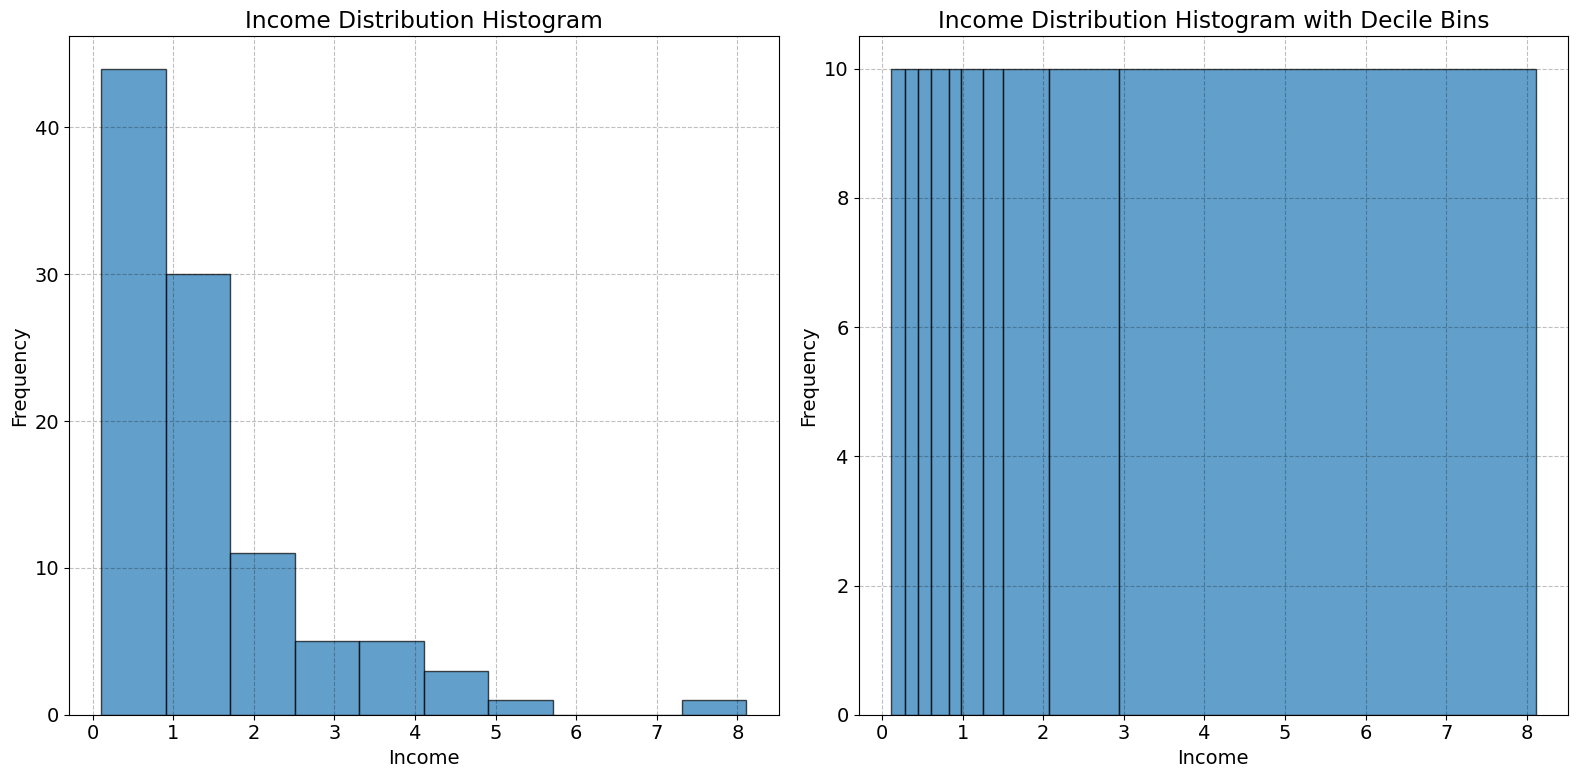

In [17]:
fig, axs = plt.subplots(1, 2, figsize=(16, 8), sharex=False)
axs[0].hist(df_true['inc'], bins=10, edgecolor='black', alpha=0.7)
axs[0].set_xlabel('Income')
axs[0].set_ylabel('Frequency')
axs[0].set_title('Income Distribution Histogram')

# Create a second subplot with the deciles being the bins
bins = [df_true['inc'].min()] + list(deciles['inc']) + [df_true['inc'].max()]
axs[1].hist(df_true['inc'], bins=bins, edgecolor='black', alpha=0.7)
axs[1].set_xlabel('Income')
axs[1].set_ylabel('Frequency')
axs[1].set_title('Income Distribution Histogram with Decile Bins')

plt.tight_layout()
plt.show()

## 2. <a id='toc2_'></a>[Inflation](#toc0_)

### 2.1. <a id='toc2_1_'></a>[Basics](#toc0_)

Using table `PRIS113` from Statistics Denmark produce figures
with, respectively,

1. The consumer price index (CPI), $P_{t}$, indexed to $100$ on average
in $2020$
1. The month-to-month inflation rate, $\pi_{t}=P_{t}/P_{t-1}-1$
1. The 12-month inflation rate, $\pi^{12}_{t}=P_{t}/P_{t-12}-1$

When did the post-pandemic inflation surge end in Denmark? 

**Hint I**: You can use the `pandas` method `.pct_change`.

**Hint II**: You can use the function `Y = pd.to_datetime(X,format='%YM%m')`
to create a date-variable, and then e.g. get the year as `Y.dt.year`


***Comment***
All the code below is from last years answer. All these questions were part of the Autumn 2025 DataProject.

In [18]:
# make a call to the api
PRIS113 = DstApi('PRIS113')

In [19]:
# get a summary to inspect the variable names
PRIS113.tablesummary(language='en')

Table PRIS113: Consumer price index by type and time
Last update: 2026-01-12T08:00:00


,variable name,# values,First value,First value label,Last value,Last value label,Time variable
0,TYPE,1,INDEKS,Consumer price index,INDEKS,Consumer price index,False
1,Tid,552,1980M01,1980M01,2025M12,2025M12,True


In [20]:
# download data using the base parameters defined in the PRIS113 class
params = PRIS113._define_base_params()
df_CPI = PRIS113.get_data(params)

# clean data
df_CPI = df_CPI.drop(columns=['TYPE'])
df_CPI['TID'] = pd.to_datetime(df_CPI['TID'],format='%YM%m') # convert to datetime so we can do (math)operations on dates
df_CPI = df_CPI.rename(columns={'TID':'date','INDHOLD':'CPI'}) # rename columns for clarity
df_CPI = df_CPI.set_index('date').sort_index() # index and sort by date for easier plotting and analysis

# c. index to 2020=100
df_CPI.CPI = df_CPI.CPI/df_CPI[df_CPI.index.year==2020].CPI.mean()*100
df_CPI.tail()

,CPI
date,
2025-08-01,117.660329
2025-09-01,117.563648
2025-10-01,118.047051
2025-11-01,117.660329
2025-12-01,117.176926


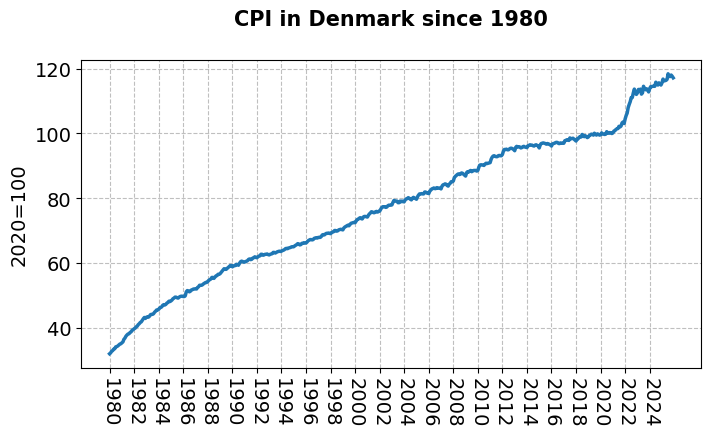

In [21]:
# plot
fig = plt.figure(figsize=(8,4))
ax = fig.add_subplot(1,1,1)

ax.plot(df_CPI.index,df_CPI.CPI,lw=2.5)

# only have ticks for every 24 months, and label them with the year
ax.set_xticks(df_CPI.index[::24]) # [::24] reads take all elements of the index, but only every 24th element
ax.set_xticklabels(df_CPI.index[::24].year,rotation=270);

ax.set_ylabel('2020=100')
ax.set_title('CPI in Denmark since 1980',
             pad=25.0,fontdict={'fontsize':15,'fontweight':'bold'});

In [22]:
# compute the month to month inflation rate as the percentage change in CPI from the previous month
df_CPI['inflation'] = df_CPI['CPI'].pct_change(periods=1,fill_method=None)*100

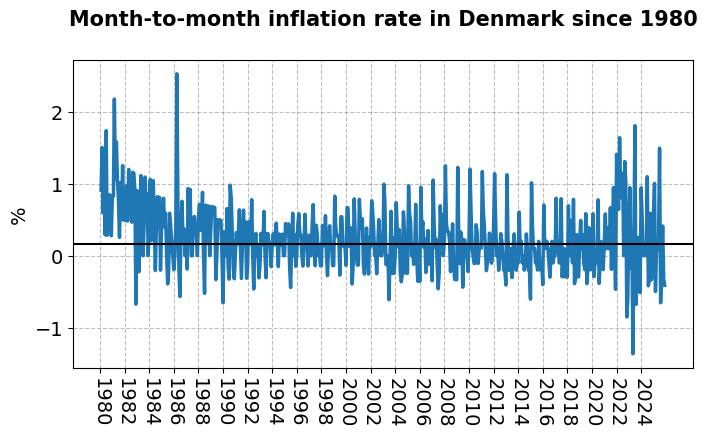

In [23]:
# plot
fig = plt.figure(figsize=(8,4))
ax = fig.add_subplot(1,1,1)

ax.plot(df_CPI.index,df_CPI['inflation'],lw=2.5)

ax.axhline(((1+0.02)**(1/12)-1)*100,color='black')

ax.set_xticks(df_CPI.index[::24])
ax.set_xticklabels(df_CPI.index[::24].year,rotation=270);

ax.set_ylabel('%')
ax.set_title('Month-to-month inflation rate in Denmark since 1980',
             pad=25.0,fontdict={'fontsize':15,'fontweight':'bold'});

In [24]:
# to get the year to year inflation rate we can use the same method, but with a period of 12 months
df_CPI['inflation_12'] = df_CPI['CPI'].pct_change(periods=12)*100

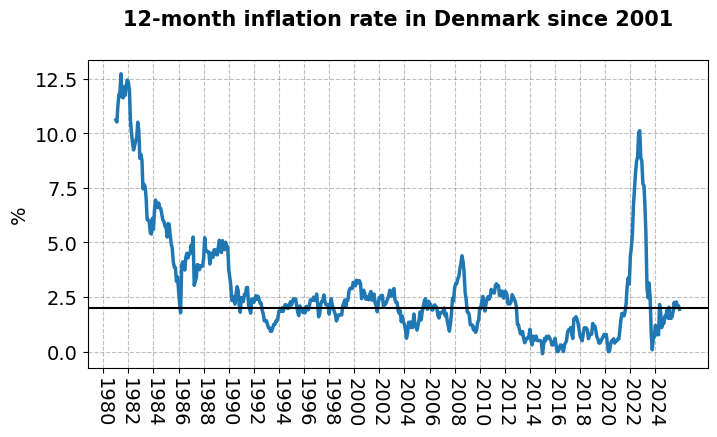

In [25]:
# plot
fig = plt.figure(figsize=(8,4))
ax = fig.add_subplot(1,1,1)

ax.plot(df_CPI.index,df_CPI['inflation_12'],lw=2.5)

ax.axhline(2.0,color='black')

ax.set_xticks(df_CPI.index[::24])
ax.set_xticklabels(df_CPI.index[::24].year,rotation=270);

ax.set_ylabel('%')
ax.set_title('12-month inflation rate in Denmark since 2001',
             pad=25.0,fontdict={'fontsize':15,'fontweight':'bold'});

### 2.2. <a id='toc2_2_'></a>[Instantaneous inflation](#toc0_)

The **instantaneous inflation rate** is defined as

$$
\begin{aligned}
\pi^{12,\alpha}_{t} &= \left(\prod_{k=0}^{11}\left(1+\pi_{t-k}\right)^{\kappa\left(k,\alpha\right)}\right)-1\\
\kappa\left(k,\alpha\right) &= \frac{\left(12-k\right)^{\alpha}}{\sum\left(12-k\right)^{\alpha}}12
\end{aligned}
$$

When $\alpha=0$ this is just the 12-month inflation rate. For higher $\alpha$ more weight is placed on inflation in the recent months.

1. Plot $\kappa(k,\alpha)$ for $k\in\{0,1,2,\dots,11\}$ and $\alpha\in\{0,1,2,3\}$
2. Compute $\pi^{12,\alpha}_{t}$ for $\alpha\in\{0,1,2,3\}$ (e.g. using the `.rolling(12).apply` method)
3. Plot $\pi^{12,\alpha}_{t}$ for $\alpha\in\{0,1,2,3\}$ since 2019

Can this be used to say something new about when the post-pandemic inflation surge ended in Denmark compared to your analysis above?

In [26]:
a_vec = np.array([0.0,1.0,2.0,3.0])
Na = a_vec.size
weights = np.zeros((Na,12))
for i_a in range(Na):
    weights[i_a] = (12-np.flip(np.arange(12)))**a_vec[i_a] # we use flip to flip the array so we get 12-11, 12-10,..., so we put more weights on earlier months
    weights[i_a] = weights[i_a]/np.sum(weights[i_a])*12

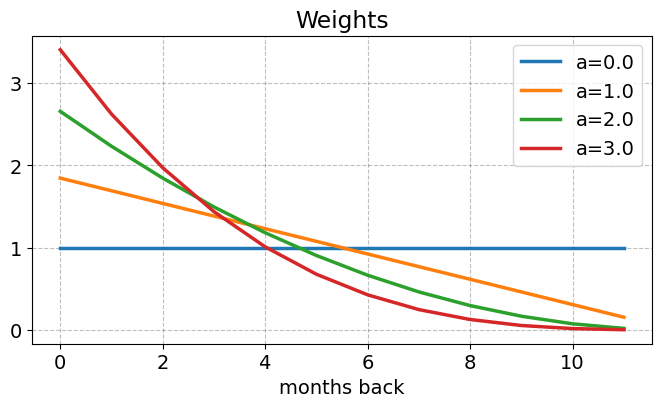

In [27]:
# plot
fig = plt.figure(figsize=(8,4))
ax = fig.add_subplot(1,1,1)

for i_a in range(Na):
    ax.plot(np.flip(np.arange(12)),weights[i_a],label=f'a={a_vec[i_a]:.1f}',lw=2.5)

ax.legend()
ax.set_xlabel('months back')
ax.set_title('Weights');

In [28]:
# write your code here
for i_a in range(Na):
    df_CPI[f'inflation_{i_a}'] = df_CPI.inflation.rolling(12).apply(lambda x: (np.prod((1+x/100)**(weights[i_a]))-1)*100)
# the rolling function creates a rolling window of 12 months and rolls one month forward each time.
# the apply then applies the function to each rolling window, x is the window of 12 months
# the function we apply is the instantaneous inflation rate

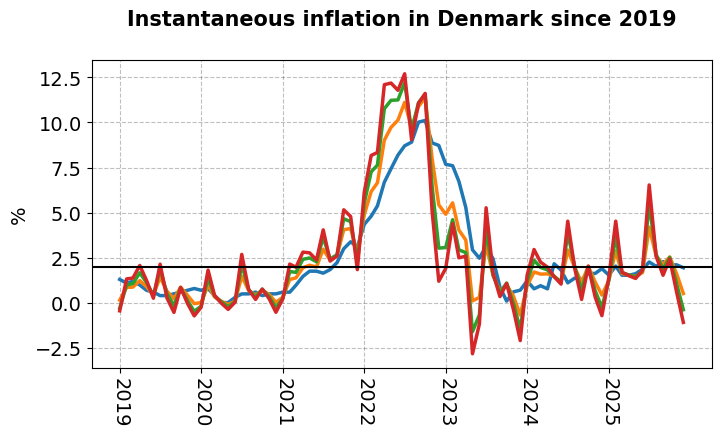

In [29]:
# plot

# selector so we only plot from 2019 and onwards
I = df_CPI.index >= pd.to_datetime(2019,format='%Y')

fig = plt.figure(figsize=(8,4))
ax = fig.add_subplot(1,1,1)

# plot for each alpha value
for i_a in range(Na):
    ax.plot(df_CPI[I].index,df_CPI[I][f'inflation_{i_a}'],lw=2.5)

ax.axhline(2,color='black')

ax.set_xticks(df_CPI[I].index[::12])
ax.set_xticklabels(df_CPI[I].index[::12].year,rotation=270);

ax.set_ylabel('%')
ax.set_title('Instantaneous inflation in Denmark since 2019',
             pad=25.0,fontdict={'fontsize':15,'fontweight':'bold'});

### 2.3. <a id='toc2_3_'></a>[Core inflation](#toc0_)

Using table `PRIS111` from Statistics Denmark produce a
figure with 12-month inflation rates since 2019 for the following
series:

1. `VAREGR = 000000`: Consumer price index, total
1. `VAREGR = 151000`: ... excl. energy
1. `VAREGR = 141000`: ... excl. energy and unprocessed food
(core inflation).

What does this tell us about the most likely drivers of the post-pandemic
inflation surge in Denmark?

In [30]:
# make a call to the api
PRIS111 = DstApi('PRIS111')

In [31]:
# inspect the meta data in the api
# we use this inspection to see the structure and find variable names and values we want to use
PRIS111.tablesummary(language='en')

Table PRIS111: Consumer price index by commodity group, unit and time
Last update: 2026-01-12T08:00:00


,variable name,# values,First value,First value label,Last value,Last value label,Time variable
0,VAREGR,385,000000,"00 Consumer price index, total",151000,15.1 Overall Consumer Price Index excl. energy,False
1,ENHED,3,100,Index,300,Percentage change compared to same month the y...,False
2,Tid,300,2001M01,2001M01,2025M12,2025M12,True


In [32]:
# make dictionaries using the variable levels method to be used to clean data later
dict_VAREGR = {row['id']: row['text'] for i,row in PRIS111.variable_levels('VAREGR',language='en').iterrows()}
dict_ENHED = {row['id']: row['text'] for i,row in PRIS111.variable_levels('ENHED',language='en').iterrows()}

In [33]:
# a. download data
params = PRIS111._define_base_params(language='en')
VAREGR = {'code': 'VAREGR', 'values': ['000000', '141000','151000']}
ENHED = {'code': 'ENHED', 'values': ['100']}
TID = {'code': 'Tid', 'values': ['*']}
params['variables'] = [VAREGR, ENHED, TID]
df_CPI_core = PRIS111.get_data(params)

# b. clean data (using the dictionaries we made above) and only keep the variables we need
df_CPI_core['VAREGR'] = df_CPI_core.VAREGR.replace(
    {dict_VAREGR['000000']: 'Total',
     dict_VAREGR['141000']: 'Core',
     dict_VAREGR['151000']: 'NonFood'
    })
df_CPI_core = df_CPI_core.rename(columns={'TID':'date','INDHOLD': 'value',})
df_CPI_core = df_CPI_core.drop(columns=['ENHED'])
df_CPI_core['date'] = pd.to_datetime(df_CPI_core['date'], format='%YM%m')
df_CPI_core['value'] = df_CPI_core.value.astype(float)

# c. pivot where we put data as row index and put the different values of VAREGR as columns
df_CPI_core = df_CPI_core.pivot_table(index='date',columns='VAREGR',values='value').rename_axis(None,axis=1)

# d. inflation rates
df_CPI_core['inflation_12_total'] = df_CPI_core['Total'].pct_change(periods=12)*100
df_CPI_core['inflation_12_non_food'] = df_CPI_core['NonFood'].pct_change(periods=12)*100
df_CPI_core['inflation_12_core'] = df_CPI_core['Core'].pct_change(periods=12)*100
df_CPI_core.tail()

,Core,NonFood,Total,inflation_12_total,inflation_12_non_food,inflation_12_core
date,,,,,,
2025-08-01,120.4,121.2,121.7,2.011735,2.451395,2.293968
2025-09-01,120.3,121.1,121.6,2.270816,2.366864,2.209006
2025-10-01,120.6,121.4,122.1,2.090301,2.447257,2.290076
2025-11-01,120.0,120.8,121.7,2.097315,2.459712,2.301790
2025-12-01,119.8,120.5,121.2,1.934399,2.378929,2.218430


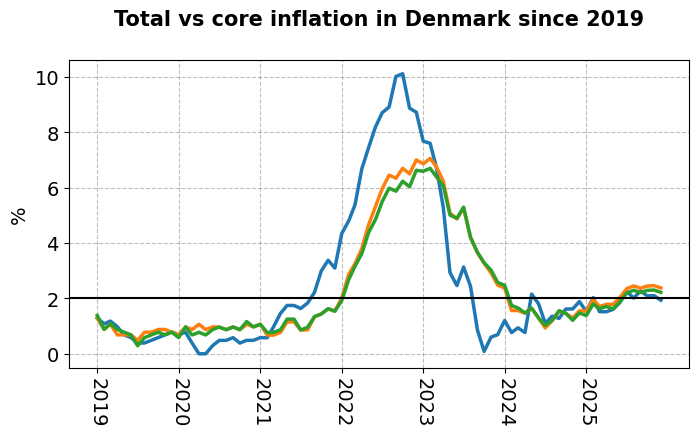

In [34]:
# plot
I = df_CPI_core.index >= pd.to_datetime(2019,format='%Y')

fig = plt.figure(figsize=(8,4))
ax = fig.add_subplot(1,1,1)

ax.plot(df_CPI_core[I]['inflation_12_total'],lw=2.5,label='Total')
ax.plot(df_CPI_core[I]['inflation_12_non_food'],lw=2.5,label='Non-food')
ax.plot(df_CPI_core[I]['inflation_12_core'],lw=2.5,label='Core')

ax.axhline(2,color='black')

ax.set_xticks(df_CPI_core[I].index[::12])
ax.set_xticklabels(df_CPI_core[I].index[::12].year,rotation=270);

ax.set_ylabel('%')
ax.set_title('Total vs core inflation in Denmark since 2019',
             pad=25.0,fontdict={'fontsize':15,'fontweight':'bold'});

### 2.4. <a id='toc2_4_'></a>[CPI vs HICP](#toc0_)

Compare the CPI from Denmark Statistics with the Harmonized Index
for Consumer Prices (HICP) from FRED code `CP0000DKM086NEST`
(All Items). Are the two indexes comparable?

In [35]:
# make a call to the FRED api
fred = Fred(api_key='10214c7fa80c9d2df2c7e14282407288')

In [36]:
# create a new dataframe holding CPI from DST and HICP from FRED
df_CPI_HICP = df_CPI.loc[:,['CPI']]
df_CPI_HICP['HICP'] = fred.get_series('CP0000DKM086NEST').rename('HICP')
# index to 2020=100
df_CPI_HICP['HICP'] = df_CPI_HICP.HICP/df_CPI_HICP[df_CPI_HICP.index.year==2020].HICP.mean()*100

In [37]:
# inspect
df_CPI_HICP.tail()

,CPI,HICP
date,,
2025-08-01,117.660329,118.583740
2025-09-01,117.563648,118.430440
2025-10-01,118.047051,119.079018
2025-11-01,117.660329,118.477609
2025-12-01,117.176926,117.958746


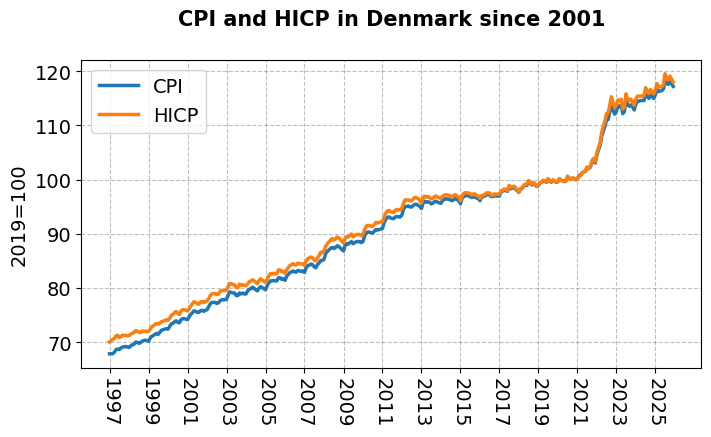

In [38]:
# plot
I = df_CPI_HICP.index >= pd.to_datetime(1997,format='%Y')

fig = plt.figure(figsize=(8,4))
ax = fig.add_subplot(1,1,1)

ax.plot(df_CPI_HICP[I].index, df_CPI_HICP[I].CPI,lw=2.5,label='CPI')
ax.plot(df_CPI_HICP[I].index, df_CPI_HICP[I].HICP,lw=2.5,label='HICP')

ax.set_xticks(df_CPI_HICP[I].index[::24])
ax.set_xticklabels(df_CPI_HICP[I].index[::24].year,rotation=270);

ax.legend()
ax.set_ylabel('2019=100')
ax.set_title('CPI and HICP in Denmark since 2001',
             pad=25.0,fontdict={'fontsize':15,'fontweight':'bold'});

### 2.5. <a id='toc2_5_'></a>[International comparison](#toc0_)

Using FRED do the following for Denmark, Austria, the Euro Area and
the United States since 2019:

1. Compare HICP (All Items) across countries
1. Compute and compare the 12-month HICP inflation rate across countries

Summarize the cross-country differences in the path of inflation since
2019.

In [39]:
# dictionaries used for renaming and the other for loading the series. Numbers have been looked up on FRED
countries = {
    'Denmark': 'Denmark',
    'Austria': 'Austria',
    'EuroArea': 'Euro Area',
    'UnitedStates': 'United States',
}

series = {
    'CP0000DKM086NEST': 'Denmark',
    'CP0000ATM086NEST': 'Austria',
    'CP0000EZ19M086NEST': 'EuroArea',
    'CP0000USM086NEST': 'UnitedStates',    
}

In [40]:
# create a new dictionary holding HICP for the countries in the series dictionary
data = {}
for code,name in series.items():
    data[name] = fred.get_series(code)
# convert dictionary to dataframe
df_int = pd.DataFrame(data)

In [41]:
# index to 2020=100
df_int = df_int/df_int[df_int.index.year==2020].mean()*100
df_int.tail()

,Denmark,Austria,EuroArea,UnitedStates
2026-02-01,118.253555,130.015486,123.345140,NaN
2026-03-01,118.218178,131.514925,124.912983,NaN
2026-04-01,118.536571,132.194158,126.186855,NaN
2026-05-01,119.267696,132.309500,126.284845,NaN
2026-06-01,119.586089,131.976291,126.162357,NaN


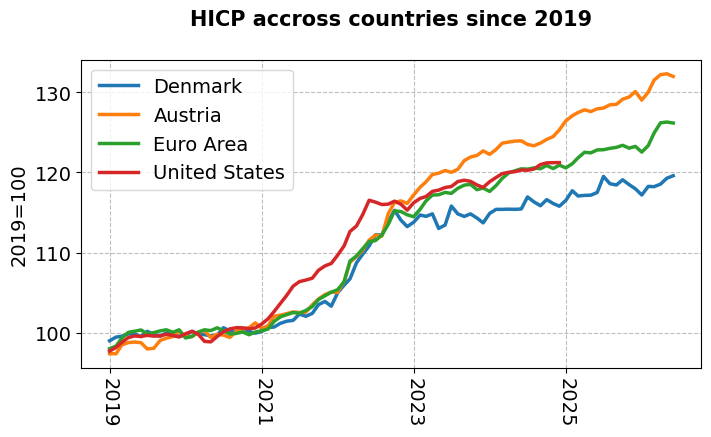

In [42]:
# plot
I = df_int.index >= pd.to_datetime(2019,format='%Y')

fig = plt.figure(figsize=(8,4))
ax = fig.add_subplot(1,1,1)

for code, name in countries.items():
    ax.plot(df_int[I].index, df_int[I][code], lw=2.5,label=name)

ax.set_xticks(df_int[I].index[::24])
ax.set_xticklabels(df_int[I].index[::24].year,rotation=270);

ax.legend()
ax.set_ylabel('2019=100')
ax.set_title('HICP accross countries since 2019',
             pad=25.0,fontdict={'fontsize': 15, 'fontweight': 'bold'});